# Course Reviews — Exploratory Data Analysis

**Dataset:** `user_courses_review_09_2023.csv` — user reviews of online courses
**Author:** Waheed

This notebook explores a dataset of course reviews (a 1-5 star rating plus an optional
text comment), as preparation for a **Naive Bayes text-classification** case study. Along
the way it handles a real-world data-loading problem and profiles the ratings, review
text, and the vocabulary that separates positive from negative reviews.

## 1. Loading the data (a real-world parsing problem)

The raw file is messy: some review comments contain **embedded newlines** and
**unescaped double-quotes**, which break the default CSV parser (`Error tokenizing data`).
Two robustness steps fix it:

- `engine="python"` correctly handles quoted fields that span multiple lines / contain commas
- `on_bad_lines="skip"` drops the small number of genuinely malformed rows (unescaped quotes)

We then coerce `review_rating` to a valid integer 1-5 (a few rows had review text leak into
the rating column).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

df = pd.read_csv("user_courses_review_09_2023.csv", engine="python", on_bad_lines="skip")

# Keep only valid 1-5 ratings
df["review_rating"] = pd.to_numeric(df["review_rating"], errors="coerce")
df = df[df["review_rating"].isin([1, 2, 3, 4, 5])].copy()
df["review_rating"] = df["review_rating"].astype(int)

# Clean text helper columns
df["comment"] = df["review_comment"].fillna("").astype(str)
df["n_words"] = df["comment"].str.split().str.len()

print(f"{len(df):,} clean reviews across {df['course_name'].nunique()} courses")
print(f"Reviews with text: {(df['comment'].str.len() > 0).sum():,} | blank: {(df['comment'].str.len() == 0).sum():,}")
df.head()

10,801 clean reviews across 99 courses
Reviews with text: 10,614 | blank: 187


,course_name,lecture_name,review_rating,review_comment,comment,n_words
0,A/B Testing in Python,How to set up the A/B test,5,If she could provide more details about the pr...,If she could provide more details about the pr...,56
1,A/B Testing in Python,How to set up the A/B test,5,nice,nice,1
2,A/B Testing in Python,How to set up the A/B test,5,excellent course,excellent course,2
3,A/B Testing in Python,How to set up the A/B test,5,nice,nice,1
4,A/B Testing in Python,Conclusion,5,It was an experiential learning process,It was an experiential learning process,6


## 2. Rating distribution

How are the 1-5 star ratings spread?

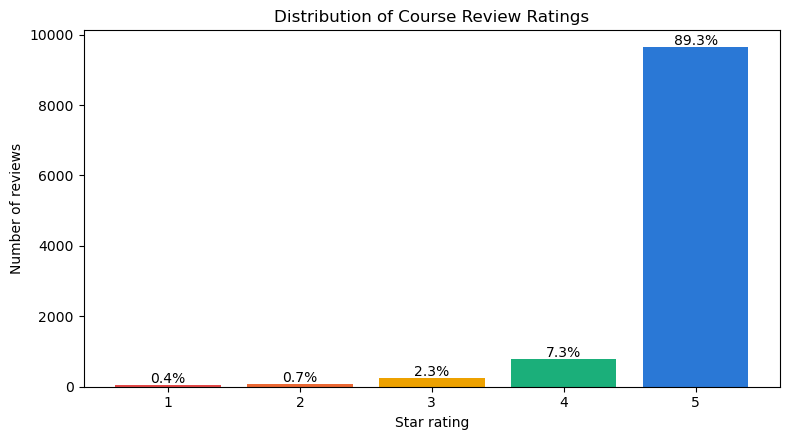

review_rating
1     0.4
2     0.7
3     2.3
4     7.3
5    89.3


In [2]:
counts = df["review_rating"].value_counts().sort_index()
colors = ["#e34948", "#eb6834", "#eda100", "#1baf7a", "#2a78d6"]
plt.figure(figsize=(8, 4.5))
plt.bar(counts.index, counts.values, color=colors)
for x, y in zip(counts.index, counts.values):
    plt.text(x, y + 60, f"{y/len(df)*100:.1f}%", ha="center", fontsize=10)
plt.xlabel("Star rating"); plt.ylabel("Number of reviews")
plt.title("Distribution of Course Review Ratings")
plt.tight_layout(); plt.show()
print((counts / len(df) * 100).round(1).to_string())

**Interpretation — ratings.**
The data is **heavily imbalanced toward 5 stars (~89%)**. This is the single most important
fact for the upcoming classifier: a trivial model that always predicts "5 stars" would reach
~89% accuracy while being useless. When we build Naive Bayes we must therefore look at
**precision/recall per class** (not just accuracy) and consider grouping ratings into
positive vs negative, or rebalancing the classes.

## 3. Review length by rating

Do happier or unhappier reviewers write more?

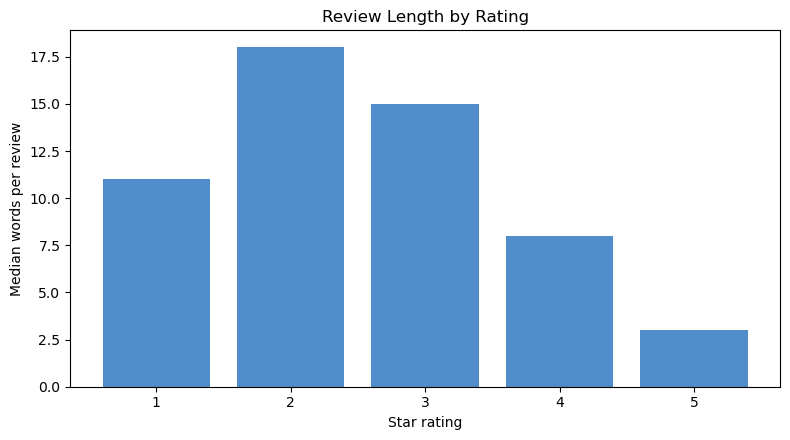

,mean,median,max
review_rating,,,
1,22.2,11.0,112
2,28.0,18.0,199
3,21.6,15.0,158
4,13.8,8.0,196
5,6.5,3.0,302


In [3]:
length = df.groupby("review_rating")["n_words"].median()
plt.figure(figsize=(8, 4.5))
plt.bar(length.index, length.values, color="#518cca")
plt.xlabel("Star rating"); plt.ylabel("Median words per review")
plt.title("Review Length by Rating")
plt.tight_layout(); plt.show()
df.groupby("review_rating")["n_words"].agg(["mean", "median", "max"]).round(1)

**Interpretation — length.**
There is a clear **inverse relationship**: 5-star reviews are extremely short (median ~3
words - often just "nice" or "great"), while 1-2 star reviews are far longer (median 11-18
words). Dissatisfied users write more to explain what went wrong. Review length is itself
almost a sentiment signal, and a candidate engineered feature for the classifier.

## 4. Most-reviewed courses

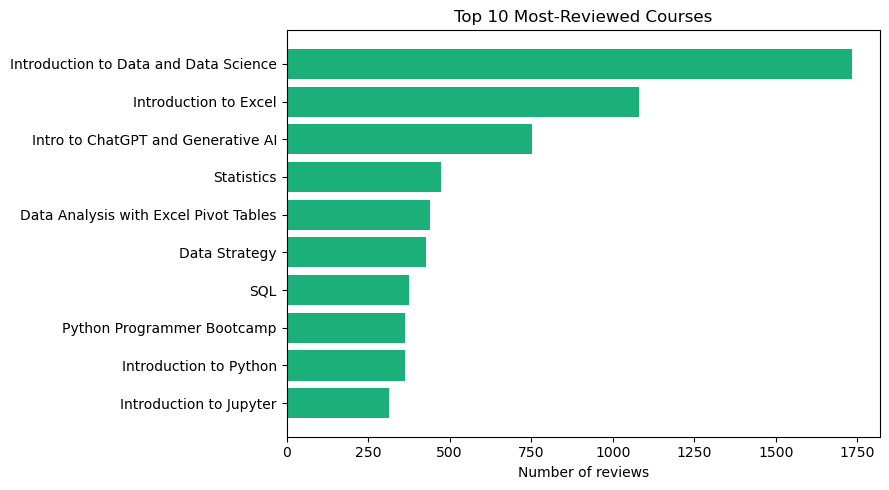

In [4]:
top_courses = df["course_name"].value_counts().head(10).iloc[::-1]
plt.figure(figsize=(9, 5))
plt.barh(top_courses.index, top_courses.values, color="#1baf7a")
plt.xlabel("Number of reviews"); plt.title("Top 10 Most-Reviewed Courses")
plt.tight_layout(); plt.show()

## 5. What words separate positive from negative reviews?

Using `CountVectorizer` (which tokenises the text and counts word frequencies in one step),
we find the most common words in 5-star reviews versus 1-2 star reviews. This is a direct
preview of the features Naive Bayes will learn from.

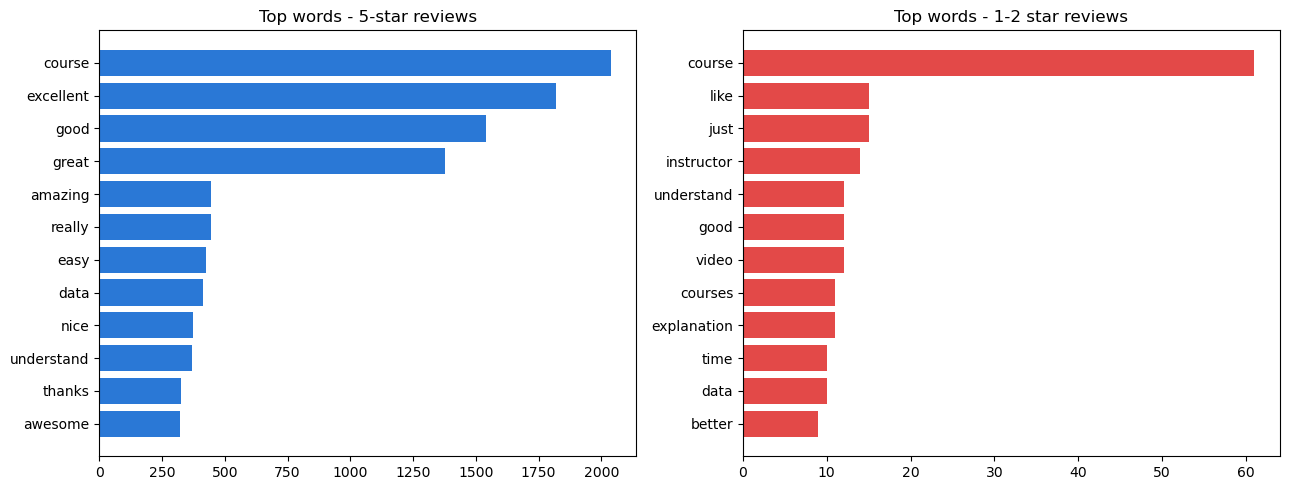

5-star  : ['course', 'excellent', 'good', 'great', 'amazing', 'really', 'easy', 'data', 'nice', 'understand', 'thanks', 'awesome']
1-2 star: ['course', 'like', 'just', 'instructor', 'understand', 'good', 'video', 'courses', 'explanation', 'time', 'data', 'better']


In [5]:
def top_words(mask, n=12):
    cv = CountVectorizer(stop_words="english", min_df=5)
    X = cv.fit_transform(df.loc[mask, "comment"])
    freq = np.asarray(X.sum(axis=0)).ravel()
    order = freq.argsort()[::-1][:n]
    return cv.get_feature_names_out()[order], freq[order]

pos_w, pos_f = top_words(df["review_rating"] == 5)
neg_w, neg_f = top_words(df["review_rating"].isin([1, 2]))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].barh(pos_w[::-1], pos_f[::-1], color="#2a78d6"); ax[0].set_title("Top words - 5-star reviews")
ax[1].barh(neg_w[::-1], neg_f[::-1], color="#e34948"); ax[1].set_title("Top words - 1-2 star reviews")
plt.tight_layout(); plt.show()

print("5-star  :", list(pos_w))
print("1-2 star:", list(neg_w))

**Interpretation — vocabulary.**
The two vocabularies separate cleanly. **Positive reviews** are dominated by pure praise
(*excellent, great, amazing, awesome, easy, thanks*). **Negative reviews** instead name
*what* disappointed them - *instructor, video, explanation, better, time* - constructive
criticism about delivery rather than generic "bad" words. These word counts are exactly the
kind of features a Naive Bayes classifier uses to separate sentiment.

## Summary

- **Loading:** the file needed a robust parser (`engine="python"`, skip bad rows) due to
  embedded newlines and unescaped quotes - a realistic data-cleaning lesson.
- **~10,800 clean reviews / 99 courses.**
- **Ratings are ~89% five-star** - severe class imbalance to handle in modelling.
- **Length falls as rating rises** - unhappy reviewers write far more.
- **Positive vs negative vocabularies are clearly distinct**, which bodes well for a text
  classifier.

**Next step:** build the Naive Bayes classifier - vectorise the comments, define the target
(e.g. positive vs negative sentiment), train `MultinomialNB`, and evaluate with attention to
the class imbalance.

<!-- DEEPER-EDA -->
# Part 2 - Deeper EDA & Modelling Prep

Building on the profile above, this section handles missing values, defines the
classification target, checks text quality, extracts the truly distinctive vocabulary,
and runs the correlation analysis - the groundwork for the Naive Bayes model.

<!-- DEEPER-EDA -->
## 6. Handling missing values

After cleaning the ratings, the only remaining gap is in `review_comment`.

In [6]:
# DEEPER-EDA
print(df[["course_name", "lecture_name", "review_comment"]].isna().sum().to_string())
blank = (df["comment"].str.len() == 0).sum()
print(f"\nBlank comments: {blank}")

course_name         0
lecture_name        0
review_comment    187

Blank comments: 187


<!-- DEEPER-EDA -->
**Interpretation.** `course_name` and `lecture_name` are complete; only ~187 rows have a
rating but a blank comment. Decision: **keep them for the rating analysis, but exclude them
from the text model** - a blank comment carries no words, so it cannot contribute features to
a bag-of-words classifier. We do *not* impute text: inventing review words would be
meaningless and would leak noise.

<!-- DEEPER-EDA -->
## 7. Defining the sentiment target (and a severe imbalance)

For classification we collapse the 1-5 scale into **positive (4-5)** vs **negative (1-2)**
and drop the ambiguous **neutral (3)**.

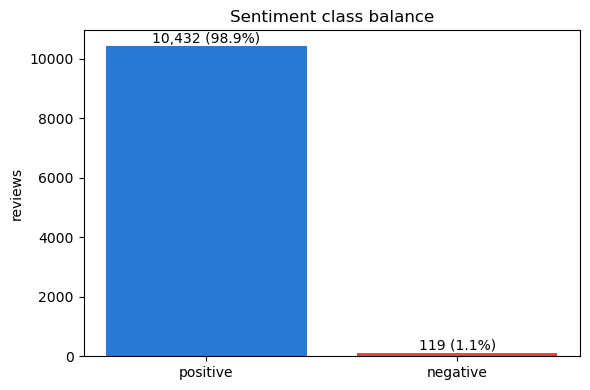

sentiment
positive    10432
negative      119


In [7]:
# DEEPER-EDA
import numpy as np
df_s = df[df["review_rating"] != 3].copy()
df_s["sentiment"] = np.where(df_s["review_rating"] >= 4, "positive", "negative")

vc = df_s["sentiment"].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(vc.index, vc.values, color=["#2a78d6", "#e34948"])
for i, v in enumerate(vc.values):
    plt.text(i, v + 100, f"{v:,} ({v/len(df_s)*100:.1f}%)", ha="center", fontsize=10)
plt.title("Sentiment class balance"); plt.ylabel("reviews")
plt.tight_layout(); plt.show()
print(vc.to_string())

<!-- DEEPER-EDA -->
**Interpretation - the core modelling challenge.**
The classes are **extremely imbalanced: ~98.9% positive, with only ~119 negative reviews**.
This dominates everything downstream:
- **Accuracy is useless** - always predicting "positive" scores ~99%.
- We must evaluate with **precision, recall and F1 on the negative class**, plus a confusion matrix.
- Techniques to consider: `class_weight="balanced"`, under-sampling the positives, or adjusting
  the decision threshold.
- With only ~119 negatives, the model has very little to learn "negative" from - expect
  negative recall to be the hard metric.

<!-- DEEPER-EDA -->
## 8. Text quality: is non-English a problem?

A bag-of-words model degrades if many reviews are in other languages, so we check before assuming.

In [8]:
# DEEPER-EDA
import re
nonascii = df["comment"].apply(lambda s: bool(re.search(r"[^\x00-\x7F]", s)))
print(f"Reviews containing non-ASCII characters: {nonascii.sum()} ({nonascii.mean()*100:.1f}%)")

Reviews containing non-ASCII characters: 161 (1.5%)


<!-- DEEPER-EDA -->
**Interpretation.** Only ~1.5% of reviews contain any non-ASCII character, and spot-checking
those shows most are English with an accented character or emoji. **Non-English text is not a
meaningful problem here**, so no language filtering is needed - a small but useful decision to
verify rather than assume.

<!-- DEEPER-EDA -->
## 9. Distinctive vocabulary - done properly (log-odds + bigrams)

Raw word counts are dominated by generic words ("course", "data") that appear in *both* classes.
A **log-odds ratio** with smoothing instead surfaces the words most *characteristic* of each
class, and adding **bigrams** captures phrases like "older version".

In [9]:
# DEEPER-EDA
from sklearn.feature_extraction.text import CountVectorizer
d = df_s[df_s["comment"].str.split().str.len() >= 2]
cv = CountVectorizer(stop_words="english", ngram_range=(1, 2), min_df=3)
X = cv.fit_transform(d["comment"]); vocab = cv.get_feature_names_out()
pos = np.asarray(X[d["sentiment"].values == "positive"].sum(0)).ravel()
neg = np.asarray(X[d["sentiment"].values == "negative"].sum(0)).ravel()
score = np.log((neg + 1)/(neg.sum() + len(vocab))) - np.log((pos + 1)/(pos.sum() + len(vocab)))
order = score.argsort()
print("Most NEGATIVE-associated terms:", [vocab[i] for i in order[::-1][:12]])
print("Most POSITIVE-associated terms:", [vocab[i] for i in order[:12]])

Most NEGATIVE-associated terms: ['poorly', 'lack', 'average', 'older version', 'older', 'course doesn', 'feels like', 'solving', 'solution', 'covered course', 'mac', 'harder']
Most POSITIVE-associated terms: ['excellent', 'amazing', 'great', 'far', 'interesting', 'easy understand', 'love', 'awesome', 'excellent course', 'helpful', 'thank', 'easy']


<!-- DEEPER-EDA -->
**Interpretation.** The two vocabularies are now genuinely informative:
- **Positive:** *excellent, amazing, great, easy understand, love, awesome, helpful* - pure
  praise, many appearing with zero negatives.
- **Negative:** *older version, version, mac, poorly, lack, harder, feels like* - concrete,
  **actionable complaints**: outdated course content, Mac compatibility, and difficulty. These
  are exactly the discriminative features Naive Bayes will rely on. (Caveat: with only ~119
  negatives the negative counts are small, so this signal is suggestive, not definitive.)

<!-- DEEPER-EDA -->
## 10. Correlation analysis

Two relationships: does review **length** track the rating, and do **courses** differ in
average rating?

Spearman correlation (review length vs rating): rho = -0.221  (p = 4.8e-120)


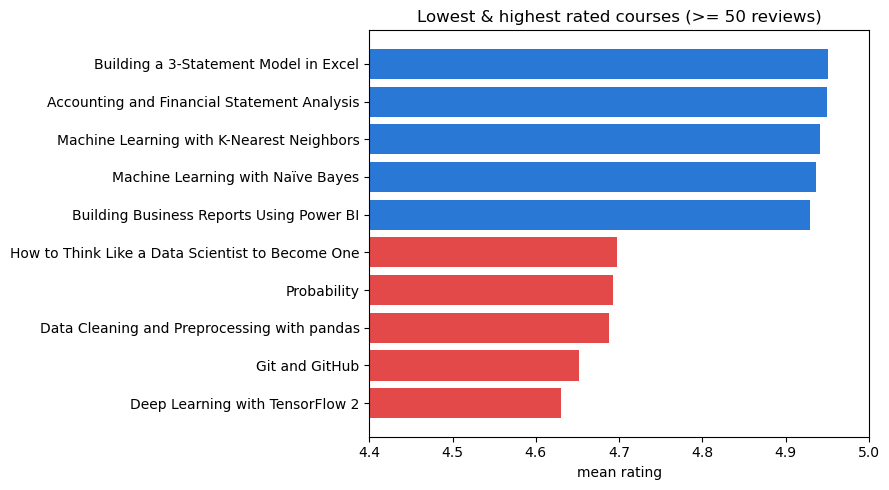

In [10]:
# DEEPER-EDA
from scipy import stats
rho, pv = stats.spearmanr(df["n_words"], df["review_rating"])
print(f"Spearman correlation (review length vs rating): rho = {rho:.3f}  (p = {pv:.1e})")

g = df.groupby("course_name")["review_rating"].agg(["mean", "count"])
g = g[g["count"] >= 50].sort_values("mean")
extremes = pd.concat([g.head(5), g.tail(5)])
plt.figure(figsize=(9, 5))
plt.barh(extremes.index, extremes["mean"], color=["#e34948"]*5 + ["#2a78d6"]*5)
plt.xlim(4.4, 5.0); plt.xlabel("mean rating")
plt.title("Lowest & highest rated courses (>= 50 reviews)")
plt.tight_layout(); plt.show()

<!-- DEEPER-EDA -->
**Interpretation.** Length and rating are **negatively correlated (Spearman rho = -0.22,
p ~ 1e-120)** - a real, statistically strong effect: longer reviews skew negative, so review
length is a useful engineered feature. At the **course** level, average ratings vary only mildly
(even the lowest sit around 4.6 and the highest near 4.95), consistent with the overall positive
skew - no course is a clear outlier.

<!-- DEEPER-EDA -->
## Part 2 summary & modelling implications

- **Missing data** is minimal (only blank comments) - dropped from the text model, not imputed.
- **Target:** positive vs negative sentiment, but with a **severe ~99/1 imbalance (~119
  negatives)** - the defining constraint for the Naive Bayes step.
- **Text is overwhelmingly English** - no language cleaning required.
- **Log-odds + bigrams** reveal real, discriminative vocabulary (praise vs outdated-content /
  compatibility complaints).
- **Length negatively correlates with rating** (rho = -0.22) - a candidate feature.

**Modelling next:** vectorise the comments, train `MultinomialNB` on the sentiment target, and
evaluate with a confusion matrix + negative-class precision/recall - using
`class_weight`/resampling to counter the imbalance.

<!-- REGEX-PATTERNS -->
# Part 3 - Regex pattern analysis of the review text

The vocabulary analysis above counted individual words. **Regular expressions** let us go a
step further and match *concepts and phrasings* - e.g. every way a reviewer complains about
pace ("too fast", "too slow", "too rushed") in a single pattern. By measuring how much more
often each pattern appears in **negative** vs **positive** reviews (the *neg/pos ratio*), we
turn fuzzy themes into a prioritised, actionable list of what to fix.

<!-- REGEX-PATTERNS -->
## 11. Theme patterns and their complaint-signal strength

                 pattern  pct_positive  pct_negative  neg_pos_ratio
  Pacing (too fast/slow)           0.1           4.2           31.3
      Content/tech issue           0.9          15.1           17.2
      Suggestion/request           1.5           6.7            4.5
Practice/examples wanted           4.1          17.6            4.4
      Instructor mention          17.6          57.1            3.3
Clarity (hard to follow)           3.7          10.1            2.8
          Recommendation           0.9           2.5            2.8


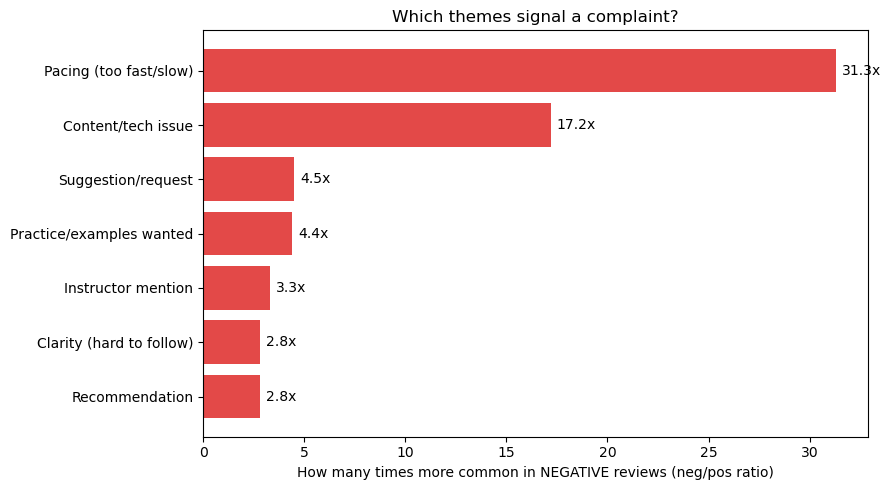

In [11]:
# REGEX-PATTERNS
import re
# Non-capturing groups (?:...) keep the patterns clean (no pandas match-group warning)
patterns = {
    "Pacing (too fast/slow)":     r"(?i)too (?:fast|slow|quick|rushed|much)",
    "Clarity (hard to follow)":   r"(?i)(?:hard|difficult|confus\w+) to (?:understand|follow)|(?:un)?clear",
    "Content/tech issue":         r"(?i)(?:audio|sound|video quality|older? version|outdated|out of date|update|mac|windows|download)",
    "Practice/examples wanted":   r"(?i)(?:example|exercise|practice|quiz|assignment|hands.?on|project|real.?world)",
    "Suggestion/request":         r"(?i)(?:please|wish|hope|suggest|would (?:be )?(?:better|nice|great|helpful) if|should (?:have|be|add))",
    "Instructor mention":         r"(?i)(?:instructor|teacher|lecturer|presenter|tutor|she |he )",
    "Recommendation":             r"(?i)\brecommend\w*",
}
pos = df_s[df_s["sentiment"] == "positive"]["comment"]
neg = df_s[df_s["sentiment"] == "negative"]["comment"]

rows = []
for name, pat in patterns.items():
    pp = pos.str.contains(pat, regex=True).mean() * 100
    pn = neg.str.contains(pat, regex=True).mean() * 100
    rows.append({"pattern": name, "pct_positive": round(pp, 1),
                 "pct_negative": round(pn, 1), "neg_pos_ratio": round(pn / pp, 1) if pp else float("inf")})
pat_df = pd.DataFrame(rows).sort_values("neg_pos_ratio", ascending=False)
print(pat_df.to_string(index=False))

r = pat_df.set_index("pattern")["neg_pos_ratio"].iloc[::-1]
plt.figure(figsize=(9, 5))
bars = plt.barh(r.index, r.values, color="#e34948")
for b, v in zip(bars, r.values):
    plt.text(v + 0.3, b.get_y() + b.get_height()/2, f"{v}x", va="center", fontsize=10)
plt.xlabel("How many times more common in NEGATIVE reviews (neg/pos ratio)")
plt.title("Which themes signal a complaint?")
plt.tight_layout(); plt.show()

<!-- REGEX-PATTERNS -->
**Interpretation.** The neg/pos ratio ranks themes by how strongly they signal dissatisfaction:
- **Pacing (~31x)** is by far the biggest complaint driver - "too fast/slow" barely appears in
  happy reviews but is common in unhappy ones.
- **Content/tech issues (~17x)** - outdated software versions, Mac compatibility, downloads -
  echo the "older version" bigram found earlier: a genuine recurring problem.
- **Practice/examples (~4x)** and **suggestions (~4x)** - unhappy reviewers ask for more
  hands-on material.
- **Instructor mentions** jump to ~57% of negative reviews: when dissatisfied, people name the
  instructor directly.

<!-- REGEX-PATTERNS -->
## 12. What do reviewers explicitly ask for more of?

A **capture group** `([a-z]+)` pulls out the word that follows "more" - extraction, not just matching.

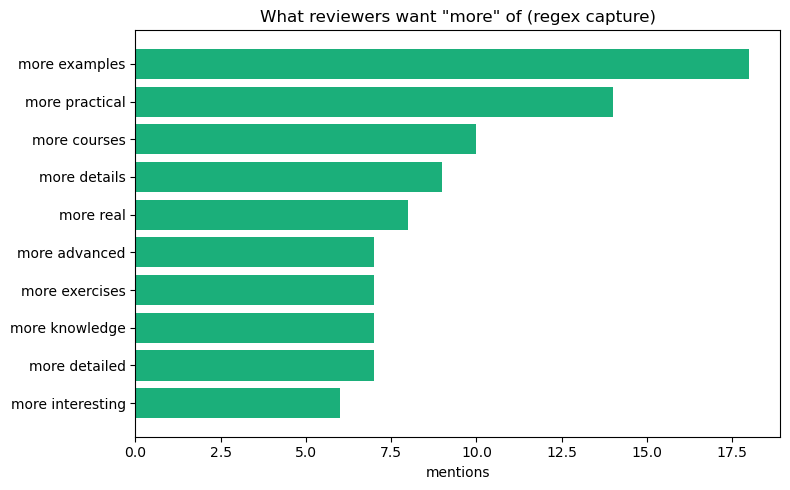

[('examples', 18), ('practical', 14), ('courses', 10), ('details', 9), ('real', 8), ('advanced', 7), ('exercises', 7), ('knowledge', 7), ('detailed', 7), ('interesting', 6)]


In [12]:
# REGEX-PATTERNS
from collections import Counter
more = Counter()
for s in df["comment"]:
    for w in re.findall(r"(?i)more ([a-z]+)", s):
        more[w.lower()] += 1
stop = {"than", "about", "and", "in", "to", "of", "the", "for", "or", "on"}
top_more = [(w, c) for w, c in more.most_common(30) if w not in stop][:10]

labels = [f"more {w}" for w, _ in top_more][::-1]
vals = [c for _, c in top_more][::-1]
plt.figure(figsize=(8, 5))
plt.barh(labels, vals, color="#1baf7a")
plt.xlabel("mentions"); plt.title('What reviewers want "more" of (regex capture)')
plt.tight_layout(); plt.show()
print(top_more)

<!-- REGEX-PATTERNS -->
**Interpretation.** Extracting the word after "more" gives a direct wish-list: reviewers
consistently ask for **more examples, more practical content, more exercises, more advanced
material, and more real-world application**. This is a concrete, product-level takeaway pulled
straight from free text by a single regex.

<!-- REGEX-PATTERNS -->
## Part 3 summary

Regex complements the word-count analysis by matching *phrasings and concepts*:
- **Pacing** and **outdated content** are the top complaint signals (31x and 17x more common in
  negative reviews).
- Reviewers explicitly want **more hands-on, practical, advanced material**.
- Captured suggestions and the neg/pos ratios turn unstructured review text into a prioritised
  list of what to improve - insight the raw ratings and word counts alone don't provide.